<a href="https://colab.research.google.com/github/aapaul29/Distance-Recognition-SML1-/blob/aaryan-workspace/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SML Project 1**

This notebook works in both **VS Code (local)** and **Google Colab**.

## **1. <u>Environment Detection & Setup</u>**

In [1]:
import sys
import os

IN_COLAB = 'google.colab' in sys.modules
print(f"Running in {'Google Colab' if IN_COLAB else 'VS Code / local'}")


Running in VS Code / local




## **2. <u>Google Colab: Mount Drive & Navigate to Project</u>**
This cell only runs on Colab. Adjust `COLAB_PROJECT_PATH` to where you uploaded the project folder in your Google Drive.

In [ ]:
# ---------------------------------------------------------------
# COLAB ONLY — skip if running locally
# Adjust this path to match your Google Drive folder structure.
COLAB_PROJECT_PATH = "/content/drive/MyDrive/Aaryan/Uni/BS-Mech-Eng-ETH-Zurich/2nd-year/Semester-4/Stochastics&Machine-Learning/Distance-Recognition-SML1-"
# ---------------------------------------------------------------

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd "$COLAB_PROJECT_PATH"
    print(f"Working directory: {os.getcwd()}")

    # Unzip data if not already extracted
    data_zip = os.path.join(COLAB_PROJECT_PATH, "data.zip")
    data_dir = os.path.join(COLAB_PROJECT_PATH, "data")
    if os.path.exists(data_zip) and not os.path.exists(data_dir):
        print("Unzipping data...")
        os.makedirs(data_dir, exist_ok=True)
        !unzip -q $data_zip -d $data_dir
        print("Done.")
    else:
        print("Data directory already exists or no zip found — skipping unzip.")
else:
    print("Local environment — no mounting needed.")

Mounted at /content/drive
/content/drive/MyDrive/Aaryan/Uni/BS-Mech-Eng-ETH-Zurich/2nd-year/Semester-4/Stochastics&Machine-Learning/Distance-Recognition-SML1-
Working directory: /content/drive/MyDrive/Aaryan/Uni/BS-Mech-Eng-ETH-Zurich/2nd-year/Semester-4/Stochastics&Machine-Learning/Distance-Recognition-SML1-
Data directory already exists or no zip found — skipping unzip.


## **3. <u>Auto-reload & Imports**</u>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import uniform, randint

#Sklearn imports
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score


from utils import load_config, load_dataset, load_test_dataset, print_results, save_results

# Add further sklearn imports here as needed.
# Note: SVRs are NOT allowed in this project.

config = load_config()

[INFO]: Configs are loaded with: 
 {'data_dir': WindowsPath('data'), 'load_rgb': True, 'downsample_factor': 5}


In [3]:
if IN_COLAB:
    import shutil
    from pathlib import Path
    src = "/content/drive/MyDrive/Aaryan/Uni/BS-Mech-Eng-ETH-Zurich/2nd-year/Semester-4/Stochastics&Machine-Learning/Distance-Recognition-SML1-/data"
    dst = "/content/data"
    if not Path(dst).exists():
        print("Copying data to local Colab storage (faster I/O)...")
        shutil.copytree(src, dst)
        print("Done.")
    else:
        print("Local data already exists — skipping copy.")
    config["data_dir"] = Path(dst)

## <u>**Feature Engineering**</u>

In [4]:
def extract_hog_features(images_flat, img_height, img_width, n_channels):
    """
    Extract HOG (Histogram of Oriented Gradients) features from flattened images.
    HOG captures edge / gradient structure which strongly correlates with depth.
    """
    hog_features = []
    for i in range(len(images_flat)):
        img = images_flat[i].reshape(img_height, img_width, n_channels) if n_channels > 1 \
              else images_flat[i].reshape(img_height, img_width)

        # Use channel_axis for multichannel images
        if n_channels > 1:
            features = hog(
                img,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                channel_axis=-1,
                feature_vector=True,
            )
        else:
            features = hog(
                img,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                feature_vector=True,
            )
        hog_features.append(features)

    return np.array(hog_features)

In [5]:
def extract_spatial_features(images_flat, img_height, img_width, n_channels):
    """
    Extract spatial statistics per image quadrant.
    Divides image into 4 quadrants and computes mean, std, min, max per quadrant.
    """
    total_pixels = img_height * img_width * n_channels
    features = []
    for i in range(len(images_flat)):
        img = images_flat[i].reshape(img_height, img_width, n_channels) if n_channels > 1 \
              else images_flat[i].reshape(img_height, img_width)

        mid_h = img_height // 2
        mid_w = img_width // 2

        quadrants = [
            img[:mid_h, :mid_w],   # top-left
            img[:mid_h, mid_w:],   # top-right
            img[mid_h:, :mid_w],   # bottom-left
            img[mid_h:, mid_w:],   # bottom-right
        ]

        row = []
        for q in quadrants:
            row.extend([q.mean(), q.std(), q.min(), q.max()])

        # Also add full-image stats
        row.extend([img.mean(), img.std(), img.min(), img.max()])
        # Add pixel intensity variance (useful depth cue)
        row.append(np.var(images_flat[i]))

        features.append(row)

    return np.array(features)


In [6]:
def build_features(images_flat, config):
    """
    Combine raw pixel features with engineered features.
    Returns the combined feature matrix.
    """
    IMAGE_SIZE = (300, 300)
    img_height = IMAGE_SIZE[0] // config["downsample_factor"]
    img_width  = IMAGE_SIZE[1] // config["downsample_factor"]
    n_channels = 3 if config["load_rgb"] else 1

    print(f"[INFO]: Image dimensions: {img_height}x{img_width}x{n_channels}")
    print(f"[INFO]: Raw pixel features: {images_flat.shape[1]}")

    # 1. HOG features
    print("[INFO]: Extracting HOG features...")
    t0 = time.time()
    hog_feats = extract_hog_features(images_flat, img_height, img_width, n_channels)
    print(f"[INFO]: HOG features: {hog_feats.shape[1]} (took {time.time()-t0:.1f}s)")

    # 2. Spatial statistics
    print("[INFO]: Extracting spatial statistics...")
    spatial_feats = extract_spatial_features(images_flat, img_height, img_width, n_channels)
    print(f"[INFO]: Spatial features: {spatial_feats.shape[1]}")

    # 3. Combine all features
    combined = np.hstack([images_flat, hog_feats, spatial_feats])
    print(f"[INFO]: Combined features: {combined.shape[1]}")

    return combined


In [7]:
images, distances = load_dataset(config, split="train")
print(f"[INFO]: Dataset loaded with {len(images)} samples.")
print(f"[INFO]: Feature dimensionality: {images.shape[1]}")
print(f"Images shape : {images.shape}")
print(f"Distances shape: {distances.shape}")
print(f"Distance range : {distances.min():.2f} m – {distances.max():.2f} m")

[INFO]: Dataset loaded with 3000 samples.
[INFO]: Feature dimensionality: 10800
Images shape : (3000, 10800)
Distances shape: (3000,)
Distance range : 0.25 m – 2.78 m


In [8]:
 # ── Feature Engineering ──────────────────────────────────────────────────
print("\n" + "="*60)
print("  FEATURE ENGINEERING")
print("="*60)
X_all = build_features(images, config)



  FEATURE ENGINEERING
[INFO]: Image dimensions: 60x60x3
[INFO]: Raw pixel features: 10800
[INFO]: Extracting HOG features...


NameError: name 'time' is not defined

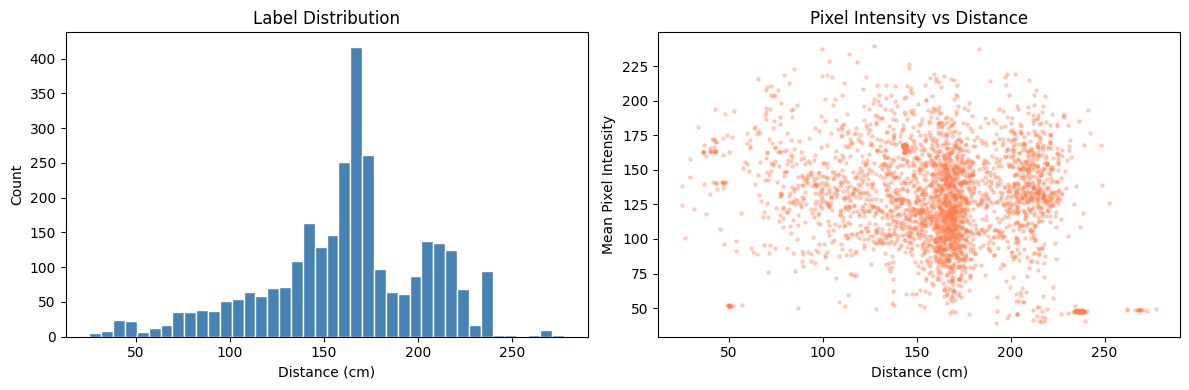

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label distribution
axes[0].hist(distances * 100, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Distance (cm)')
axes[0].set_ylabel('Count')
axes[0].set_title('Label Distribution')

# Mean pixel intensity vs distance
mean_intensity = images.mean(axis=1)
axes[1].scatter(distances * 100, mean_intensity, alpha=0.3, s=5, color='coral')
axes[1].set_xlabel('Distance (cm)')
axes[1].set_ylabel('Mean Pixel Intensity')
axes[1].set_title('Pixel Intensity vs Distance')

plt.tight_layout()
plt.show()

## **4. <u>ML Model Implementation**</u>
Implement preprocessing, model training, data split and evaluation.

**4.1. <u>Creating Splits</u>**

train (70%) | val (15%) | test (15%)
Why three splits?
         

* train  → the model learns from this
* val    → we tune hyperparameters on this (never used for fitting)
* test   → final local evaluation; simulates the private Kaggle set
* random_state=42 keeps the split identical every run (reproducibility)




         
    
      

In [10]:
# First split off the test set (15 %)
X_trainval, X_test, y_trainval, y_test = train_test_split(
        images, distances,
        test_size=0.15,
        random_state=42)

# Then split the remaining 85 % into train (≈70 %) and val (≈15 %)
# 0.15 / 0.85 ≈ 0.176  →  gives us ~15 % of the total as validation
X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval,
        test_size=0.176,
        random_state=42)

print(f"[INFO]: Split sizes — train: {len(X_train)}, "
          f"val: {len(X_val)}, test: {len(X_test)}")

[INFO]: Split sizes — train: 2101, val: 449, test: 450


In [12]:
# ── Preprocessing ────────────────────────────────────────────────────────────
N_COMPONENTS = 200 ## tune this {50, 100, 150, 200, ...}

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train only
X_val_scaled   = scaler.transform(X_val)          # transform only
X_test_scaled  = scaler.transform(X_test)         # transform only

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"[INFO]: Scaling done.")
print(f"        Feature mean (train, first 5): {X_train_scaled.mean(axis=0)[:5].round(4)}")
print(f"        Feature std  (train, first 5): {X_train_scaled.std(axis=0)[:5].round(4)}")

explained = pca.explained_variance_ratio_.cumsum()[-1] * 100
print(f"PCA with {N_COMPONENTS} components explains {explained:.1f}% of variance")
print(f"Reduced feature shape: {X_train_pca.shape}")

[INFO]: Scaling done.
        Feature mean (train, first 5): [ 0.  0. -0.  0.  0.]
        Feature std  (train, first 5): [1. 1. 1. 1. 1.]
PCA with 200 components explains 95.2% of variance
Reduced feature shape: (2101, 200)


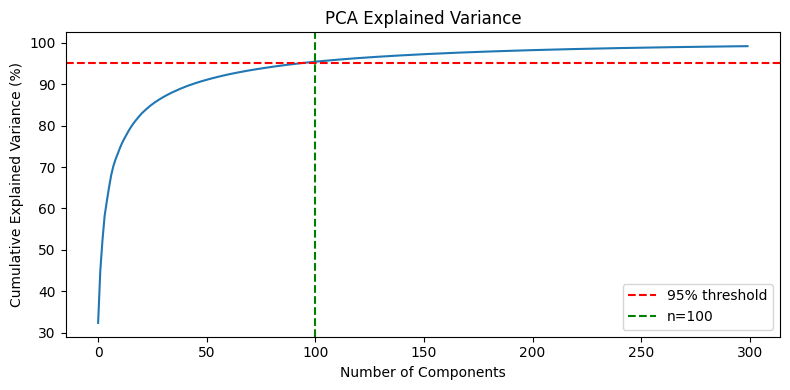

In [8]:
# Plot cumulative explained variance to help choose n_components
pca_full = PCA(n_components=min(300, X_train_scaled.shape[1]), random_state=42)
pca_full.fit(X_train_scaled)

cum_var = pca_full.explained_variance_ratio_.cumsum()
plt.figure(figsize=(8, 4))
plt.plot(cum_var * 100)
plt.axhline(95, color='red', linestyle='--', label='95% threshold')
plt.axvline(N_COMPONENTS, color='green', linestyle='--', label=f'n={N_COMPONENTS}')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
#Model definition & training
## Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_pca, y_train)

val_pred_ridge = ridge.predict(X_val_pca)
mae_ridge = mean_absolute_error(y_val, val_pred_ridge) * 100
print(f"Ridge  — Val MAE: {mae_ridge:.2f} cm")

Ridge  — Val MAE: 25.74 cm


In [ ]:
# ── HistGradientBoostingRegressor (tuned via RandomizedSearchCV) ──────────
print("\n[INFO]: Running RandomizedSearchCV for HGBR (this may take a while)...")

param_dist = {
    'learning_rate': uniform(0.01, 0.19),       # uniform between 0.01 and 0.20
    'max_depth':     randint(3, 15),             # integers 3..14
    'max_iter':      randint(200, 2001),         # integers 200..2000
    'min_samples_leaf': randint(1, 30),          # integers 1..29
    'l2_regularization': uniform(0.0, 1.0),      # uniform between 0 and 1
    'max_leaf_nodes': randint(20, 100),           # integers 20..99
}

random_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_dist,
    n_iter=80,
    scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
random_search.fit(X_train_pca, y_train)

best_hgbr = random_search.best_estimator_
print(f"Best HGBR params: {random_search.best_params_}")



val_pred_hgbr = hgbr.predict(X_val_pca)
mae_hgbr = mean_absolute_error(y_val, val_pred_hgbr) * 100
r2_hgbr  = r2_score(y_val, val_pred_hgbr) * 100
print(f"HGBR  — Val MAE: {mae_hgbr:.2f} cm  |  R²: {r2_hgbr:.1f}%")


[INFO]: Running RandomizedSearchCV for HGBR (this may take a while)...
Fitting 5 folds for each of 80 candidates, totalling 400 fits


In [ ]:
# ── ExtraTreesRegressor ──────────────────────────────────────────────────
etr = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
)
etr.fit(X_train_pca, y_train)
val_pred_etr = etr.predict(X_val_pca)
mae_etr = mean_absolute_error(y_val, val_pred_etr) * 100
r2_etr  = r2_score(y_val, val_pred_etr) * 100
print(f"ExtraTrees              — Val MAE: {mae_etr:.2f} cm  |  R²: {r2_etr:.1f}%")


In [ ]:
# ── KNeighborsRegressor ──────────────────────────────────────────────────
# After PCA, KNN in low-dimensional space is very effective for this task
best_knn_mae = float('inf')
best_k = 5
for k in [3, 5, 7, 10, 15, 20]:
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance', n_jobs=-1)
    knn.fit(X_train_pca, y_train)
    pred = knn.predict(X_val_pca)
    mae = mean_absolute_error(y_val, pred) * 100
    if mae < best_knn_mae:
        best_knn_mae = mae
        best_k = k

knn_model = KNeighborsRegressor(n_neighbors=best_k, weights='distance', n_jobs=-1)
knn_model.fit(X_train_pca, y_train)
val_pred_knn = knn_model.predict(X_val_pca)
mae_knn = mean_absolute_error(y_val, val_pred_knn) * 100
r2_knn  = r2_score(y_val, val_pred_knn) * 100
print(f"KNN (k={best_k}, weighted)  — Val MAE: {mae_knn:.2f} cm  |  R²: {r2_knn:.1f}%")


In [ ]:
# ── MLPRegressor (Neural Network) ────────────────────────────────────────
mlp = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42,
    )

mlp.fit(X_train_pca, y_train)
val_pred_mlp = mlp.predict(X_val_pca)
mae_mlp = mean_absolute_error(y_val, val_pred_mlp) * 100
r2_mlp  = r2_score(y_val, val_pred_mlp) * 100
print(f"MLP (256-128-64)        — Val MAE: {mae_mlp:.2f} cm  |  R²: {r2_mlp:.1f}%")


In [ ]:
# ── AdaBoostRegressor ────────────────────────────────────────────────────
ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=6),
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
)

ada.fit(X_train_pca, y_train)
val_pred_ada = ada.predict(X_val_pca)
mae_ada = mean_absolute_error(y_val, val_pred_ada) * 100
r2_ada  = r2_score(y_val, val_pred_ada) * 100
print(f"AdaBoost                — Val MAE: {mae_ada:.2f} cm  |  R²: {r2_ada:.1f}%")


In [ ]:
# ── Diverse Stacking ─────────────────────────────────────────────────────
# Key: use DIVERSE base learners (tree-based + distance-based + linear + neural)
print("\n[INFO]: Training stacking ensemble (diverse base learners)...")

stack_estimators = [
    ('hgbr', HistGradientBoostingRegressor(
        **random_search.best_params_, random_state=42)),
    ('etr', ExtraTreesRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=5,
        n_jobs=-1, random_state=42)),
    ('knn', KNeighborsRegressor(
        n_neighbors=best_k, weights='distance', n_jobs=-1)),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(128, 64), max_iter=500,
        early_stopping=True, random_state=42)),
    ('ridge', Ridge(alpha=10.0)),
]

stack = StackingRegressor(
    estimators=stack_estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
)

stack.fit(X_train_pca, y_train)

val_pred_stack = stack.predict(X_val_pca)
mae_stack = mean_absolute_error(y_val, val_pred_stack) * 100
r2_stack  = r2_score(y_val, val_pred_stack) * 100
print(f"Stacking (diverse)      — Val MAE: {mae_stack:.2f} cm  |  R²: {r2_stack:.1f}%")



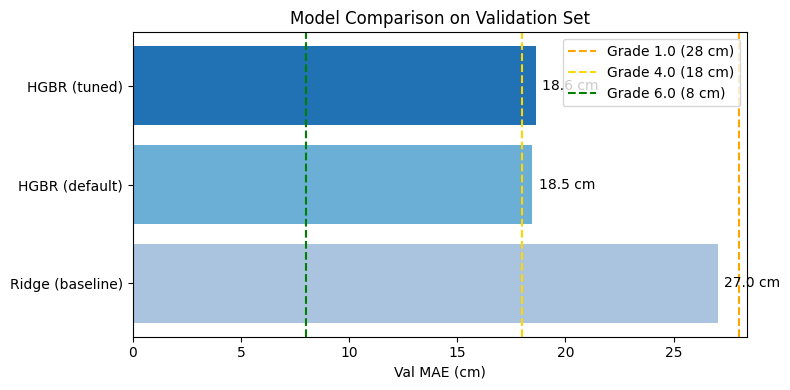

In [12]:
##Model Comparison 
results = {
    'Ridge (baseline)': mae_ridge,
    'HGBR (default)':   mae_hgbr,
    'HGBR (tuned)':     mae_best,
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(results.keys()), list(results.values()), color=['#aac4e0', '#6baed6', '#2171b5'])
ax.axvline(28, color='orange', linestyle='--', label='Grade 1.0 (28 cm)')
ax.axvline(18, color='gold',   linestyle='--', label='Grade 4.0 (18 cm)')
ax.axvline(8,  color='green',  linestyle='--', label='Grade 6.0 (8 cm)')
ax.set_xlabel('Val MAE (cm)')
ax.set_title('Model Comparison on Validation Set')
ax.legend()
for bar, val in zip(bars, results.values()):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f} cm', va='center')
plt.tight_layout()
plt.show()

In [13]:
# Evaluation on training / validation set
# Swap best_hgbr for stack if stacking was better
final_model = best_hgbr

test_pred = final_model.predict(X_test_pca)
print("=== FINAL TEST SET RESULTS ===")
print_results(y_test, test_pred)


=== FINAL TEST SET RESULTS ===
MAE: 19.43
R2: 63.676


In [14]:
# ── Retrain on full labelled dataset ─────────────────────────────────────────
X_all_scaled = scaler.fit_transform(images)         # refit scaler on all data
X_all_pca    = pca.fit_transform(X_all_scaled)      # refit PCA on all data

final_model.set_params(**grid_search.best_params_)  # keep best hyperparams
final_model.fit(X_all_pca, distances)
print("Final model retrained on full dataset")

# ── Load and transform Kaggle test images ────────────────────────────────────
kaggle_images = load_test_dataset(config)
kaggle_images = np.array(kaggle_images)

kaggle_scaled = scaler.transform(kaggle_images)
kaggle_pca    = pca.transform(kaggle_scaled)

kaggle_pred = final_model.predict(kaggle_pca)

save_results(kaggle_pred)
print(f"Saved prediction.csv with {len(kaggle_pred)} predictions")
print(f"Predicted distance range: {kaggle_pred.min():.2f} m – {kaggle_pred.max():.2f} m")

Final model retrained on full dataset
Saved prediction.csv with 622 predictions
Predicted distance range: 0.42 m – 2.66 m
